In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW


import matplotlib.pyplot as plt

In [2]:
V = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'
parameters = {'V0' : 1.448e-10, 'A' : 2.044880e-3, 'phi0' : 4.850001, 'sigma': 2.524999e-2}
potential = PotentialFunction.function(V, param_values=parameters) 

#Creando instancia de la clase Background. 
background = Background(potential, phi0 = 6.3) 
background.solver()

/home/fpineda94/Documentos/Code/primordialpy/src/primordialpy/background.py:56: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V / kinetic_term)


In [3]:
#Extrayendo datos de la clase background
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(74.77747774777478)

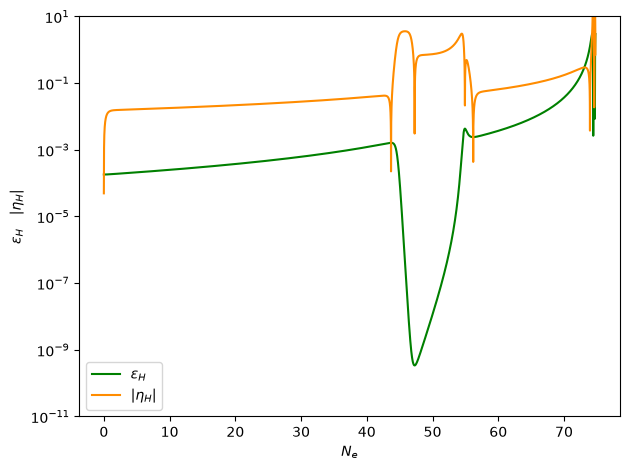

In [4]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.ylim(1e-11, 1e1)
plt.yscale('log')
plt.xlabel(r'$N_e$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')
plt.tight_layout()

In [5]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
sol_pivot = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.0282643404042416e-09
Tensor to scalar ratio at pivot scale is 0.00467855003330519


In [6]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:39<00:00, 25.22it/s]


Saved to ./Data/power_spectra.dat


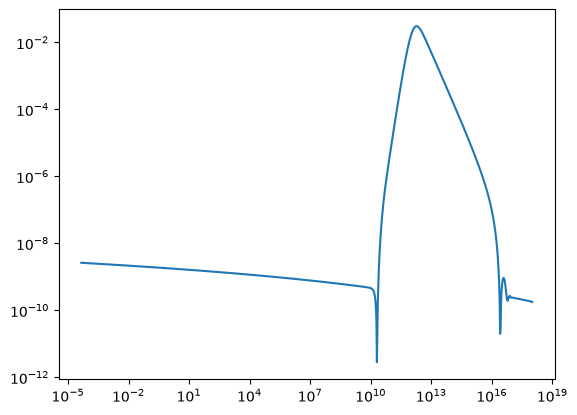

In [7]:
plt.loglog(pert.k_modes, PS[0])

In [8]:
print(pert.spectral_tilts)

{'n_s': 0.9601515864851852, 'n_t': -0.0006086717488174861}


## PBH Abundance after re-entry horizon in RD era

In [9]:
pbh = PBHAbundance(perturbations=pert, delta_c=0.4, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH()
pbh.save_pbh(path='./Data')

fPBH_peak = 0.3555046787743073
MPBH_peak = 1.0660053605391447e-12 M⊙
Saved to ./Data/pbh_abundance.dat


Failed to read 'CMB.txt': the number of columns changed from 2 to 1 at row 9; use `usecols` to select a subset and avoid this error


<Axes: title={'center': 'Observational Constraints'}, xlabel='$M_{\\rm PBH}\\ [M_\\odot]$', ylabel='$f_{\\rm PBH}(M)$'>

<Figure size 2400x1500 with 0 Axes>

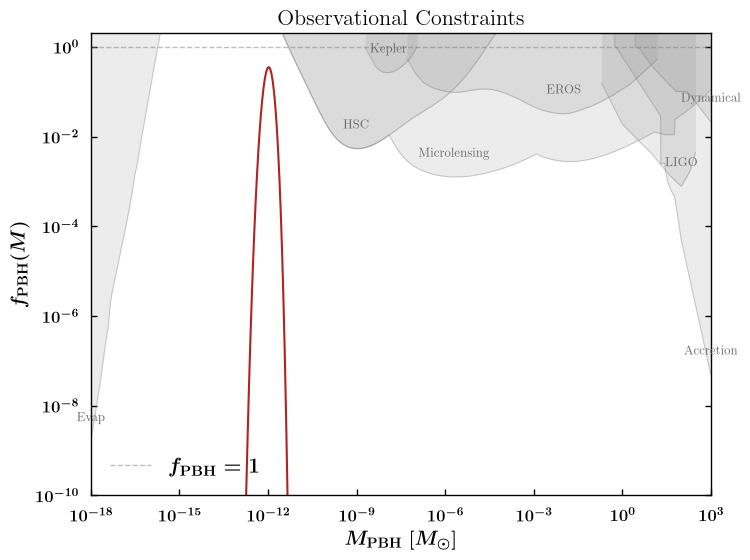

In [10]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')

constraints.plot_constraints(m_pbh=mPBH, f_pbh=fPBH)


Computing SIGW for 1000 modes...
Omega_GW_peak = 8.361419574851515e-09
f_peak = 0.0032292098907619267 Hz
Saved to ./Data/gw_data.dat


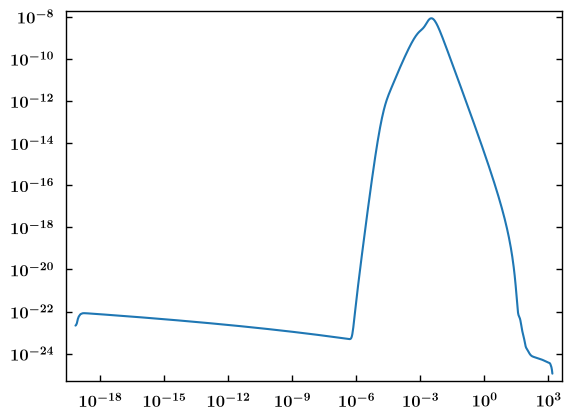

In [11]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 500)
gw.save_gw(path= './Data')
plt.loglog(f, omega)